In [14]:
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
# Load dataset
adata = ad.read_h5ad("../data/deduplicated_anndata.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 341035 × 0
    obs: 'MHC_gene_1', 'PMID', 'antigen_name', 'antigen_species', 'epitope_sequence', 'iedb_iri', 'source_organism', 'tissue', 'MHC_class', 'MHC_gene_2', 'source'
    uns: 'chain_indices', 'iggytop_metadata'
    obsm: 'airr', 'chain_indices'


In [16]:
# Convert to dataframe
df = adata.obs

print("\nShape:", df.shape)
print("\nColumns:", df.columns)



Shape: (341035, 11)

Columns: Index(['MHC_gene_1', 'PMID', 'antigen_name', 'antigen_species',
       'epitope_sequence', 'iedb_iri', 'source_organism', 'tissue',
       'MHC_class', 'MHC_gene_2', 'source'],
      dtype='object')


In [17]:
df

,MHC_gene_1,PMID,antigen_name,antigen_species,epitope_sequence,iedb_iri,source_organism,tissue,MHC_class,MHC_gene_2,source
cell_id,,,,,,,,,,,
0_ITRAP,B0801,PMID: 37133356; 10XGenomics|https://www.10xgen...,BZLF1,Epstein-Barr virus,RAKFKQLL,iedb:53128,Homo sapiens,PBMC,None,None,ITRAP|TRAIT|VDJDB
1_ITRAP,B0801,PMID: 37133356; 10XGenomics,BZLF1,Epstein-Barr virus,RAKFKQLL,iedb:53128,Homo sapiens,PBMC,None,None,ITRAP
2_ITRAP,A0201,PMID: 37133356; 10XGenomics|https://www.10xgen...,Flu MP,Influenza,GILGFVFTL,iedb:20354,Homo sapiens,PBMC,None,None,ITRAP|TRAIT|VDJDB
3_ITRAP,B0801,PMID: 37133356; 10XGenomics|https://www.10xgen...,BZLF1,Epstein-Barr virus,RAKFKQLL,iedb:53128,Homo sapiens,PBMC,None,None,ITRAP|TRAIT|VDJDB
4_ITRAP,B0801,PMID: 37133356; 10XGenomics|https://www.10xgen...,BZLF1,Epstein-Barr virus,RAKFKQLL,iedb:53128,Homo sapiens,PBMC,None,None,ITRAP|TRAIT|VDJDB
...,...,...,...,...,...,...,...,...,...,...,...
51481_TRAIT,HLA-DQA1*03:01,34433824,HIPL11C,Homo sapiens,GQVELGGGPGAGSCQ,iedb:1857536,Homo sapiens,PBMC,II,HLA-DQB1*03:02,TRAIT
51482_TRAIT,HLA-DQA1*03:01,34433824,CpepL11C,Homo sapiens,GQVELGGGPGAGSCQ,iedb:1857536,Homo sapiens,PBMC,II,HLA-DQB1*03:02,TRAIT
51485_TRAIT,HLA-DQA1*03:01,34433824,CpepL11C,Homo sapiens,GQVELGGGPGAGSCQ,iedb:1857536,Homo sapiens,PBMC,II,HLA-DQB1*03:02,TRAIT


In [18]:
# Basic overview
print("\nMissing values:\n", df.isnull().sum())

print("\nMHC class distribution:\n", df["MHC_class"].value_counts())

print("\nTop organisms:\n", df["antigen_species"].value_counts().head(10))

print("\nEpitope length stats:")
df["epitope_length"] = df["epitope_sequence"].str.len()
print(df["epitope_length"].describe())


Missing values:
 MHC_gene_1          0
PMID                0
antigen_name        0
antigen_species     0
epitope_sequence    0
iedb_iri            0
source_organism     0
tissue              0
MHC_class           0
MHC_gene_2          0
source              0
dtype: int64

MHC class distribution:
 MHC_class
I       312220
II       16680
nan       6335
None      5800
Name: count, dtype: int64

Top organisms:
 antigen_species
Severe acute respiratory syndrome coronavirus 2    97246
Homo sapiens herpesvirus 4                         48403
Homo sapiens                                       48105
Cytomegalovirus                                    39732
Influenza A virus                                  24652
Homo sapiens herpesvirus 5                         21240
Epstein-Barr virus                                 11341
Influenza                                           6049
nan                                                 6014
Hepatitis B virus                                   4254
Na

In [19]:
sns.set(style="whitegrid")

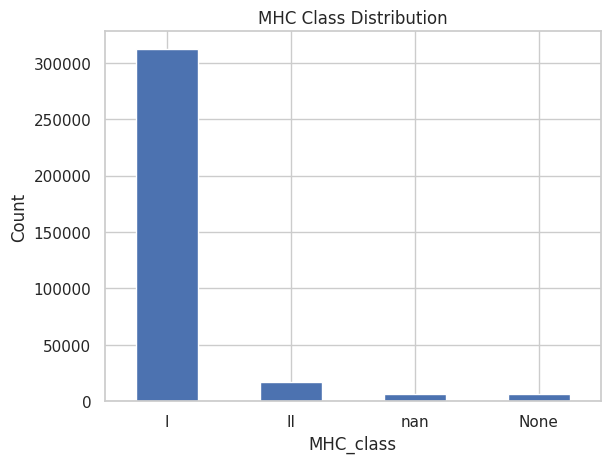

In [20]:
df["MHC_class"].value_counts(dropna=False).plot(kind="bar")
plt.title("MHC Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

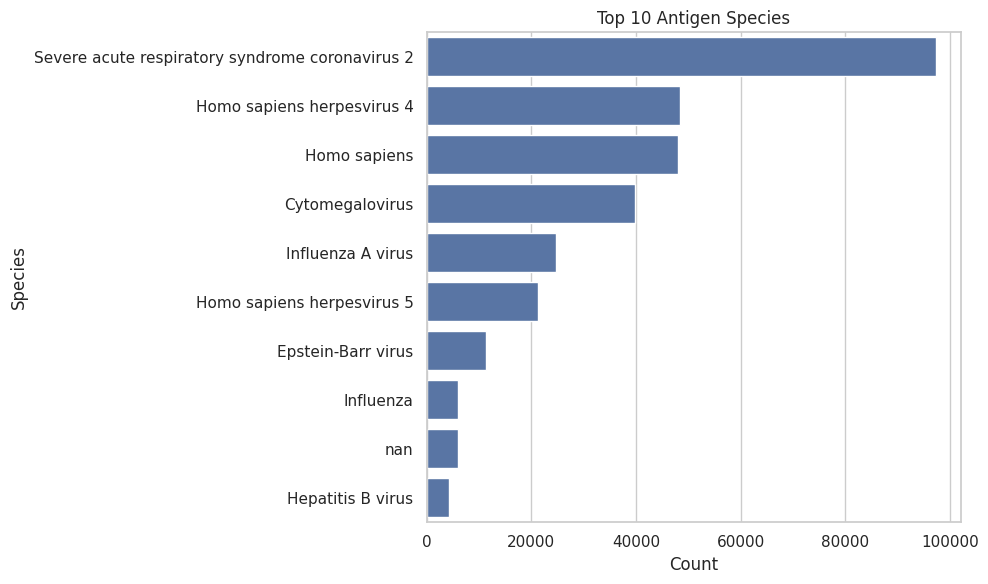

In [21]:

top_species = adata.obs['antigen_species'].value_counts().head(10)

# convertir a string SOLO para el plot
labels = top_species.index.astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_species.values, y=labels)

plt.title("Top 10 Antigen Species")
plt.xlabel("Count")
plt.ylabel("Species")

plt.tight_layout()
plt.show()

NAN

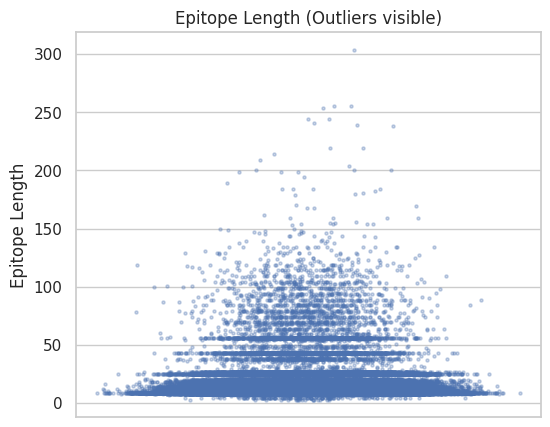

In [22]:
import numpy as np

plt.figure(figsize=(6,5))

y = adata.obs['epitope_length']
x = np.random.normal(0, 0.02, size=len(y))  # jitter para dispersar puntos

plt.scatter(x, y, alpha=0.3, s=5)

plt.xticks([])
plt.ylabel("Epitope Length")
plt.title("Epitope Length (Outliers visible)")

plt.show()

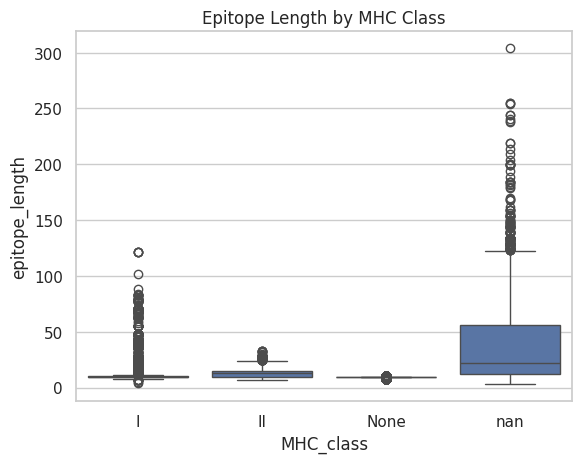

In [23]:
plt.figure()
sns.boxplot(x="MHC_class", y="epitope_length", data=df)
plt.title("Epitope Length by MHC Class")
plt.show()

In [24]:
adata.obs['MHC_class'].unique()

['None', 'I', 'II', 'nan']
Categories (4, object): ['I', 'II', 'None', 'nan']

In [25]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="upsetplot"
)

In [26]:
df_nuls = adata.obs.copy()

results = []

for col in df_nuls.columns:
    col_data = df_nuls[col]
    
    # isnull / isna
    isnull_count = col_data.isnull().sum()
    isna_count = col_data.isna().sum()
    
    # np.isnan (solo funciona en numéricos)
    try:
        isnan_count = np.isnan(col_data).sum()
    except:
        isnan_count = np.nan  # no aplica
    
    # string "nan"
    string_nan_count = (col_data == 'nan').sum()
    
    results.append({
        "column": col,
        "isnull": isnull_count,
        "isna": isna_count,
        "np.isnan": isnan_count,
        "'nan' (string)": string_nan_count
    })

missing_df = pd.DataFrame(results).set_index("column")

missing_df.sort_values(by="'nan' (string)", ascending=False)

,isnull,isna,np.isnan,'nan' (string)
column,,,,
antigen_name,0,0,NaN,6397
MHC_gene_1,0,0,NaN,6338
MHC_class,0,0,NaN,6335
antigen_species,0,0,NaN,6014
PMID,0,0,NaN,296
source_organism,0,0,NaN,53
MHC_gene_2,0,0,NaN,11
epitope_sequence,0,0,NaN,0
tissue,0,0,NaN,0


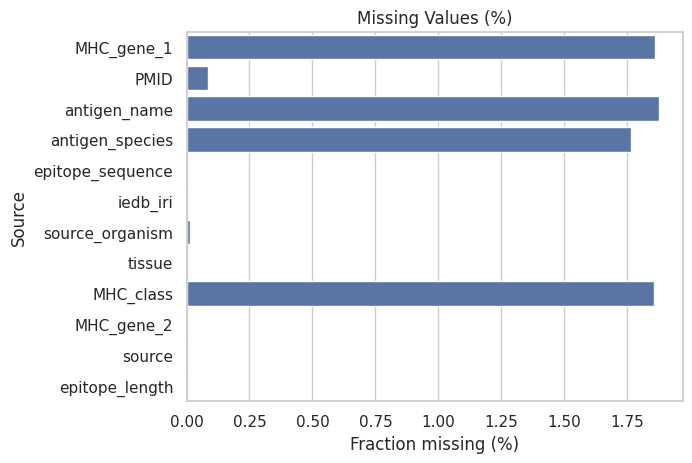

In [27]:
plt.figure()
sns.barplot(
    x=(missing_df["'nan' (string)"] / len(df)) * 100, y=missing_df.index)
plt.title("Missing Values (%)")
plt.xlabel("Fraction missing (%)")
plt.ylabel("Source")
plt.show()

In [28]:
# número de columnas que estás evaluando
n_cols = df_nuls.shape[1]

# contar TODOS los 'nan' (string) por fila
nan_per_row = (df_nuls == 'nan').sum(axis=1)

# sumar por source
nan_by_source = nan_per_row.groupby(df["source"], observed = True).sum()

nan_by_source.sort_values(ascending=False).to_frame(name="missing_cells_number")[nan_by_source > 0]

/tmp/ipykernel_8005/1543445727.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nan_by_source.sort_values(ascending=False).to_frame(name="missing_cells_number")[nan_by_source > 0]


,missing_cells_number
source,
IEDB,14686
CEDAR|IEDB,9124
MCPAS,514
NEOTCR,404
VDJDB,255
CEDAR|IEDB|NEOTCR,186
TCR3D,169
CEDAR|IEDB|TRAIT,34
TRAIT,21


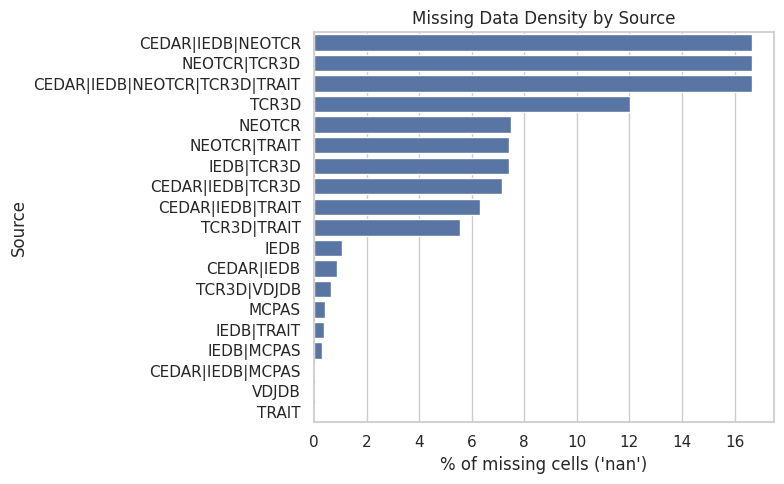

In [29]:

# número de filas por source
rows_per_source = df.groupby("source", observed=True).size()

# total de celdas por source
total_cells = rows_per_source * n_cols

# porcentaje real de missing
nan_percentage_cells = (nan_by_source / total_cells) * 100

# limpiar
nan_percentage_cells = nan_percentage_cells[nan_percentage_cells > 0].copy()
nan_percentage_cells.index = nan_percentage_cells.index.astype(str)

# ordenar
nan_percentage_cells = nan_percentage_cells.sort_values(ascending=False)

# tabla
nan_percentage_cells.to_frame(name="missing_cells (%)")

plt.figure(figsize=(8,5))

sns.barplot(
    x=nan_percentage_cells.values,
    y=nan_percentage_cells.index
)

plt.xlabel("% of missing cells ('nan')")
plt.ylabel("Source")
plt.title("Missing Data Density by Source")

plt.tight_layout()
plt.show()

In [30]:
target_source = "ITRAP"

df_target = df[df["source"] == target_source].copy()

df_target

,MHC_gene_1,PMID,antigen_name,antigen_species,epitope_sequence,iedb_iri,source_organism,tissue,MHC_class,MHC_gene_2,source,epitope_length
cell_id,,,,,,,,,,,,
1_ITRAP,B0801,PMID: 37133356; 10XGenomics,BZLF1,Epstein-Barr virus,RAKFKQLL,iedb:53128,Homo sapiens,PBMC,None,None,ITRAP,8
14_ITRAP,A1101,PMID: 37133356; 10XGenomics,EBNA 3B,Epstein-Barr virus,IVTDFSVIK,iedb:29466,Homo sapiens,PBMC,None,None,ITRAP,9
19_ITRAP,A1101,PMID: 37133356; 10XGenomics,EBNA 3B,Epstein-Barr virus,AVFDRKSDAK,iedb:5316,Homo sapiens,PBMC,None,None,ITRAP,10
22_ITRAP,A0201,PMID: 37133356; 10XGenomics,Flu MP,Influenza,GILGFVFTL,iedb:20354,Homo sapiens,PBMC,None,None,ITRAP,9
26_ITRAP,A1101,PMID: 37133356; 10XGenomics,EBNA 3B,Epstein-Barr virus,IVTDFSVIK,iedb:29466,Homo sapiens,PBMC,None,None,ITRAP,9
...,...,...,...,...,...,...,...,...,...,...,...,...
5793_ITRAP,A0301,PMID: 37133356; 10XGenomics,EMNA 3A,Epstein-Barr virus,RLRAEAQVK,iedb:54728,Homo sapiens,PBMC,None,None,ITRAP,9
5794_ITRAP,A1101,PMID: 37133356; 10XGenomics,EBNA 3B,Epstein-Barr virus,IVTDFSVIK,iedb:29466,Homo sapiens,PBMC,None,None,ITRAP,9
5795_ITRAP,A0301,PMID: 37133356; 10XGenomics,IE-1,Cytomegalovirus,KLGGALQAK,iedb:31883,Homo sapiens,PBMC,None,None,ITRAP,9


In [31]:
df_target['antigen_name'].unique()


['BZLF1', 'EBNA 3B', 'Flu MP', 'Negative Control', 'IE-1', ..., 'WT1', 'LMP1', 'NY-ESO-1', 'WT-1', 'RT']
Length: 26
Categories (2460, object): ['1D (VP1)', '2-aminomuconic semialdehyde dehydrogenase', '2-oxoglutarate dehydrogenase E1 component', '2-oxoglutarate dehydrogenase complex componen..., ..., '{3)-beta-D-Galp-(1->4)-beta-D-Glcp-(1->6)--be..., 'ß2m', 'αIIbß3 integrin', 'αvβ8 integrin']

In [32]:
from upsetplot import UpSet, from_indicators

# separar sources
df["source_split"] = df["source"].str.split("|")

# convertir a formato binario (one-hot)
df_exploded = df.explode("source_split")

sources_dummies = (
    pd.get_dummies(df_exploded["source_split"])
    .groupby(df_exploded.index)
    .max()
)

# asegurar booleanos
sources_dummies = sources_dummies.astype(bool)

# crear estructura upset
upset_data = from_indicators(sources_dummies.columns, sources_dummies)

# plot
UpSet(
    upset_data,
    show_counts=True,
    min_subset_size=1  
).plot()

plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

<Figure size 2711.11x622.222 with 4 Axes>